In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from backtester.data.loader import load_ticker_with_cache
from backtester.metrics.metrics import daily_returns

# Load Reliance
df = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2024-12-31")
prices = df["Close"]

# Compute returns
returns = daily_returns(prices)

print("First 5 prices:")
print(prices.head())
print("\nFirst 5 returns:")
print(returns.head())
print(f"\nNumber of returns: {len(returns.dropna())}")

Loading RELIANCE.NS from cache
First 5 prices:
Date
2020-01-01    675.324219
2020-01-02    686.821228
2020-01-03    687.648865
2020-01-06    671.700684
2020-01-07    682.034485
Name: Close, dtype: float64

First 5 returns:
Date
2020-01-01         NaN
2020-01-02    0.017024
2020-01-03    0.001205
2020-01-06   -0.023192
2020-01-07    0.015385
Name: Close, dtype: float64

Number of returns: 1236


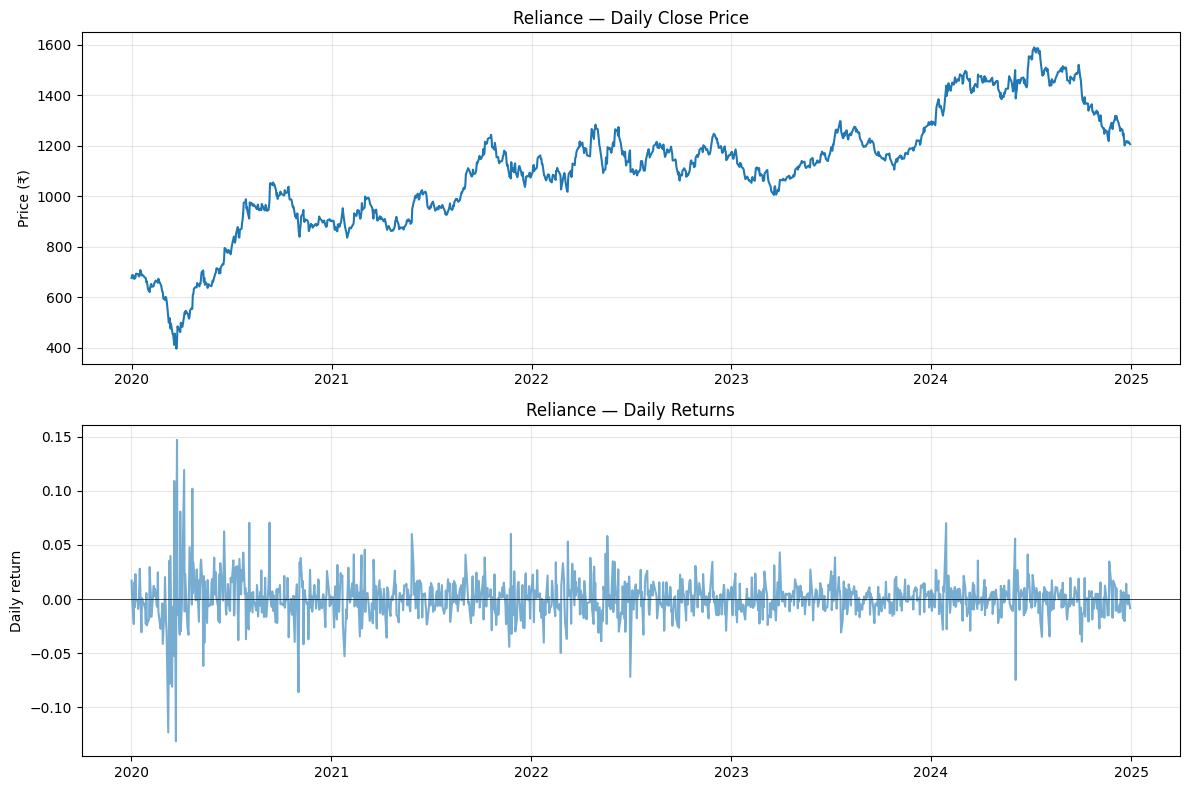

In [2]:
#Visualizing the returns

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: prices
axes[0].plot(prices.index, prices.values)
axes[0].set_title("Reliance — Daily Close Price")
axes[0].set_ylabel("Price (₹)")
axes[0].grid(True, alpha=0.3)

# Bottom: returns
axes[1].plot(returns.index, returns.values, alpha=0.6)
axes[1].set_title("Reliance — Daily Returns")
axes[1].set_ylabel("Daily return")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
from backtester.metrics.metrics import total_returns

#compute Reliance total return over 5 years (2020-2025)
total = total_returns(returns)
print(f"Reliance total return over past 5 years: {total:.2%}")

Reliance total return over past 5 years: 78.56%


In [4]:
#sanity check if we got correct returns
manual = (prices.iloc[-1] / prices.iloc[0]) - 1
print(f"From prices directly: {manual:.2%}")
print(f"From returns:         {total:.2%}")

#Both values must be same.

From prices directly: 78.56%
From returns:         78.56%


In [5]:
"""Getting CAGR"""
from backtester.metrics.metrics import annualized_returns_CAGR

annual = annualized_returns_CAGR(returns)
print(f"Reliance annualized return: {annual:.2%}")

Reliance annualized return: 12.55%


In [6]:
#veryfying the CAGR math
total = total_returns(returns)
years = len(returns.dropna()) / 252

manual_annualized = (1 + total) ** (1 / years) - 1
print(f"Manual:    {manual_annualized:.2%}")
print(f"Function:  {annual:.2%}")

Manual:    12.55%
Function:  12.55%


In [7]:
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50

data = load_multiple_tickers(NIFTY_50, "2020-01-01", "2025-12-31")
prices_all = get_close_prices(data)
prices_all = prices_all.dropna(axis=1, how = "all") #drop empty stocks

returns_all = daily_returns(prices_all)


Loading RELIANCE.NS ...
Loading RELIANCE.NS from cache
Loading TCS.NS ...
Loading TCS.NS from cache
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache
Loading INFY.NS ...
Loading INFY.NS from cache
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache
Loading ITC.NS ...
Loading ITC.NS from cache
Loading LT.NS ...
Loading LT.NS from cache
Loading KOTAKBANK.NS ...
Loading KOTAKBANK.NS from cache
Loading AXISBANK.NS ...
Loading AXISBANK.NS from cache
Loading SBIN.NS ...
Loading SBIN.NS from cache
Loading BAJFINANCE.NS ...
Loading BAJFINANCE.NS from cache
Loading ASIANPAINT.NS ...
Loading ASIANPAINT.NS from cache
Loading MARUTI.NS ...
Loading MARUTI.NS from cache
Loading HCLTECH.NS ...
Loading HCLTECH.NS from cache
Loading SUNPHARMA.NS ...
Loading SUNPHARMA.NS from cache
Loading TITAN.NS ...
Loading TITAN.NS from cache
Loading ULTRACEMCO.NS ...
Loading ULTRACEMCO.NS 

In [8]:
annualized_per_stock = {}
for ticker in returns_all.columns:
    annualized_per_stock[ticker] = annualized_returns_CAGR(returns_all[ticker])
    
    #annualized_per_stock = returns_all.apply(annualized_return) shortcut Pandas
    
annualized_per_stock = pd.Series(annualized_per_stock)
annualized_sorted = annualized_per_stock.sort_values(ascending=False)

print("Top 10 by annualized returns:")    
print((annualized_sorted.head(10) * 100).round(2).astype(str) + "%")

print("\n Bottom 10:")
print((annualized_sorted.tail(10) * 100).round(2).astype(str) + "%")

Top 10 by annualized returns:
BAJFINANCE.NS    42.86%
ADANIENT.NS      41.38%
BAJAJFINSV.NS    32.36%
TITAN.NS         28.01%
EICHERMOT.NS      26.4%
BRITANNIA.NS     26.12%
JSWSTEEL.NS      23.97%
BPCL.NS          23.78%
MARUTI.NS        22.12%
ADANIPORTS.NS    21.61%
dtype: str

 Bottom 10:
CIPLA.NS         12.53%
HEROMOTOCO.NS    12.38%
COALINDIA.NS      11.8%
SUNPHARMA.NS     10.61%
HDFCLIFE.NS      10.47%
WIPRO.NS          9.36%
ITC.NS            9.25%
DRREDDY.NS        8.83%
ONGC.NS           6.82%
INDUSINDBK.NS     6.63%
dtype: str


In [9]:
"""Testing annualized volatility"""
from backtester.metrics.metrics import annualized_volatility

df = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
prices = df["Close"]
returns = daily_returns(prices)

volatility = annualized_volatility(returns)
print(f"Annualized volatility: {volatility:.2f} ")
print(f"Annualized volatility in percentage: {volatility:.2%} ")

Loading RELIANCE.NS from cache
Annualized volatility: 0.30 
Annualized volatility in percentage: 29.74% 


In [10]:
#sanity check
import numpy as np
dailty_vol = returns.dropna().std()
annual_vol = dailty_vol * np.sqrt(252)
print(f"Annualised volatility: {annual_vol:.2f}")
print(f"Annualised volatility in percentage: {annual_vol:.2%}")

Annualised volatility: 0.30
Annualised volatility in percentage: 29.74%


In [ ]:
"""Comparing annualized returns vs annualized_volatility for multiple tickers NIFTY 50"""
data = load_multiple_tickers(NIFTY_50, "2020-01-01", "2025-12-31")
prices_all = get_close_prices(data)
returns_all = daily_returns(prices_all)

print(f"{'Ticker':<15} {'Return':>8} {'Vol':>8} {'Return/Vol':>12}") #alignment syntaxes > right, < left
print("-" * 47)

for ticker in NIFTY_50:
    r = annualized_returns_CAGR(returns_all[ticker])
    v = annualized_volatility(returns_all[ticker])
    
    ratio = r/v if v>0 else 0
    print(f"{ticker:<15} {r:>7.2%} {v:>7.2%} {ratio:>11.2f}") 

Loading RELIANCE.NS ...
Loading RELIANCE.NS from cache
Loading TCS.NS ...
Loading TCS.NS from cache
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache
Loading INFY.NS ...
Loading INFY.NS from cache
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache
Loading ITC.NS ...
Loading ITC.NS from cache
Loading LT.NS ...
Loading LT.NS from cache
Loading KOTAKBANK.NS ...
Loading KOTAKBANK.NS from cache
Loading AXISBANK.NS ...
Loading AXISBANK.NS from cache
Loading SBIN.NS ...
Loading SBIN.NS from cache
Loading BAJFINANCE.NS ...
Loading BAJFINANCE.NS from cache
Loading ASIANPAINT.NS ...
Loading ASIANPAINT.NS from cache
Loading MARUTI.NS ...
Loading MARUTI.NS from cache
Loading HCLTECH.NS ...
Loading HCLTECH.NS from cache
Loading SUNPHARMA.NS ...
Loading SUNPHARMA.NS from cache
Loading TITAN.NS ...
Loading TITAN.NS from cache
Loading ULTRACEMCO.NS ...
Loading ULTRACEMCO.NS 